1. Data Exploration

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [25]:
# Read data
data_path = Path("../data/Raw_prod_data.xlsx")
df = pd.read_excel(data_path)
df = df.sort_values("DATEPRD")
print(df.head())

# Inspect dataset dimension
print("Dataset shape:", df.shape)

     DATEPRD  WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2007-09-01  NO 15/9-F-4 AH                5693           15/9-F-4   
1 2007-09-01  NO 15/9-F-5 AH                5769           15/9-F-5   
2 2007-09-02  NO 15/9-F-4 AH                5693           15/9-F-4   
3 2007-09-02  NO 15/9-F-5 AH                5769           15/9-F-5   
4 2007-09-03  NO 15/9-F-4 AH                5693           15/9-F-4   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  AVG_CHOKE_UOM  AVG_WHP_P  \
0            NaN                    NaN  ...            NaN 

In [26]:
# Check column names and data types
print(df.dtypes)

DATEPRD                     datetime64[ns]
WELL_BORE_CODE                      object
NPD_WELL_BORE_CODE                   int64
NPD_WELL_BORE_NAME                  object
NPD_FIELD_CODE                       int64
NPD_FIELD_NAME                      object
NPD_FACILITY_CODE                    int64
NPD_FACILITY_NAME                   object
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERATURE           float64
AVG_DP_TUBING                      float64
AVG_ANNULUS_PRESS                  float64
AVG_CHOKE_SIZE_P                   float64
AVG_CHOKE_UOM                       object
AVG_WHP_P                          float64
AVG_WHT_P                          float64
DP_CHOKE_SIZE                      float64
BORE_OIL_VOL                       float64
BORE_GAS_VOL                       float64
BORE_WAT_VOL                       float64
BORE_WI_VOL                        float64
FLOW_KIND                           object
WELL_TYPE  

2. Data preprocessing

In [27]:
# Drop unneccessary columns such as metadata columns and gas/water columns.
df = df.drop(columns=['NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_CHOKE_UOM', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL', 'WELL_TYPE'], axis = 1)

In [28]:
# Identify operating wells by checking flow kind
print(df.groupby("FLOW_KIND")["BORE_OIL_VOL"].describe())

             count         mean          std  min     25%     50%     75%  \
FLOW_KIND                                                                   
injection      0.0          NaN          NaN  NaN     NaN     NaN     NaN   
production  9161.0  1095.631548  1323.538151  0.0  190.69  557.55  1345.2   

                max  
FLOW_KIND            
injection       NaN  
production  5901.84  


Injection wells do not produce any oil, so it is save to exclude them. 

In [29]:
# Identify injection wells
injection_wells = df.loc[df["FLOW_KIND"].str.lower().eq("injection"), "WELL_BORE_CODE"].unique()
print(injection_wells)

['NO 15/9-F-4 AH' 'NO 15/9-F-5 AH']


In [30]:
# Remove injection wells
df = df[~df["WELL_BORE_CODE"].isin(injection_wells)]

wells = df['WELL_BORE_CODE'].unique()
print(wells)

['NO 15/9-F-12 H' 'NO 15/9-F-14 H' 'NO 15/9-F-11 H' 'NO 15/9-F-15 D'
 'NO 15/9-F-1 C']


There are 5 operating wells in total. We only choose one well predict oil production.

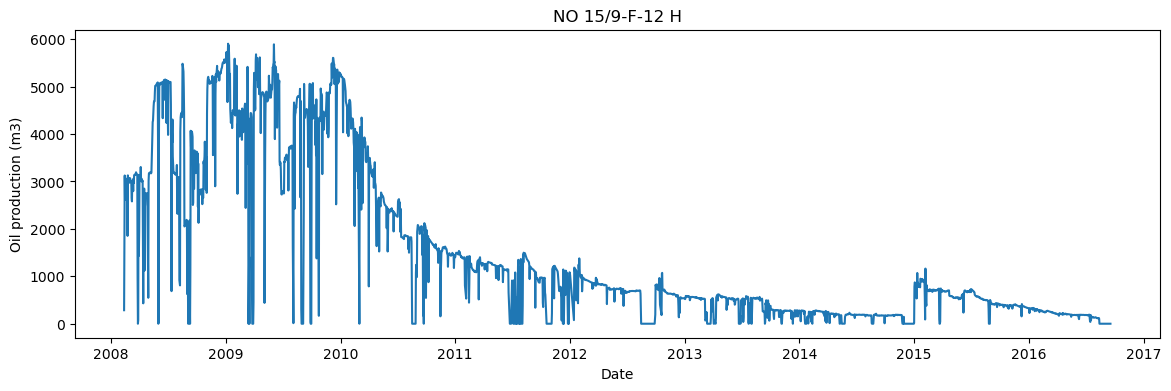

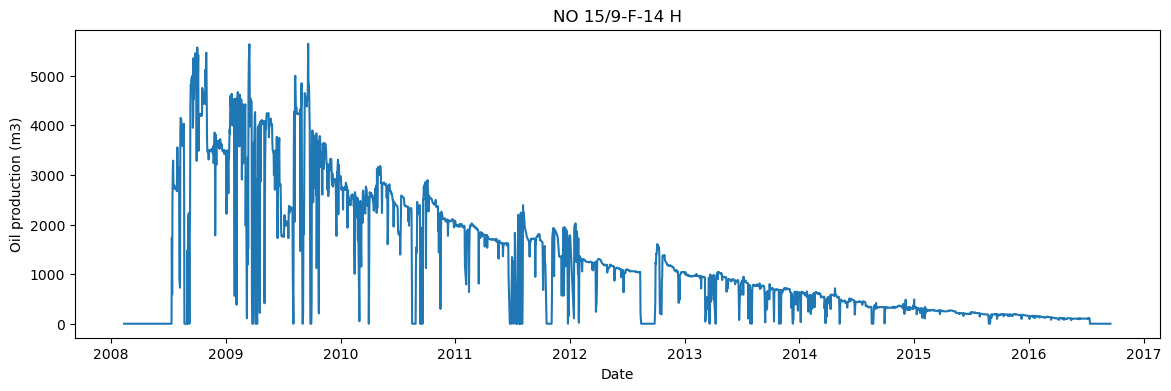

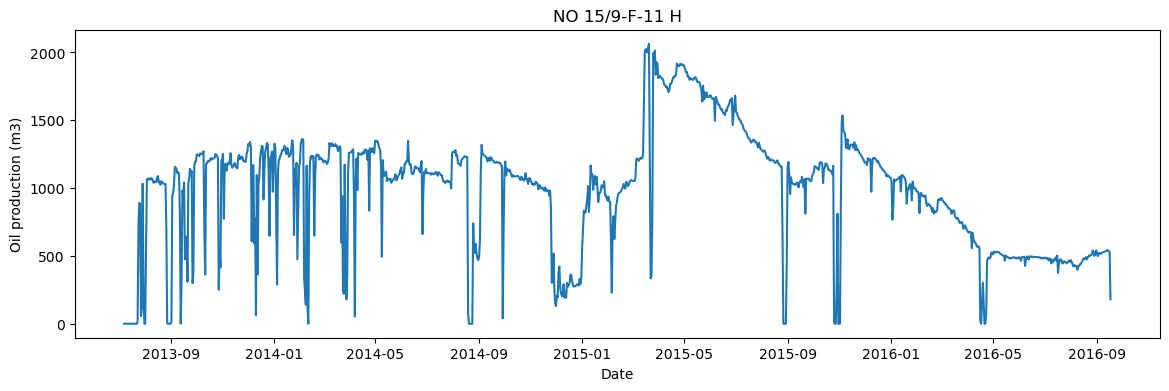

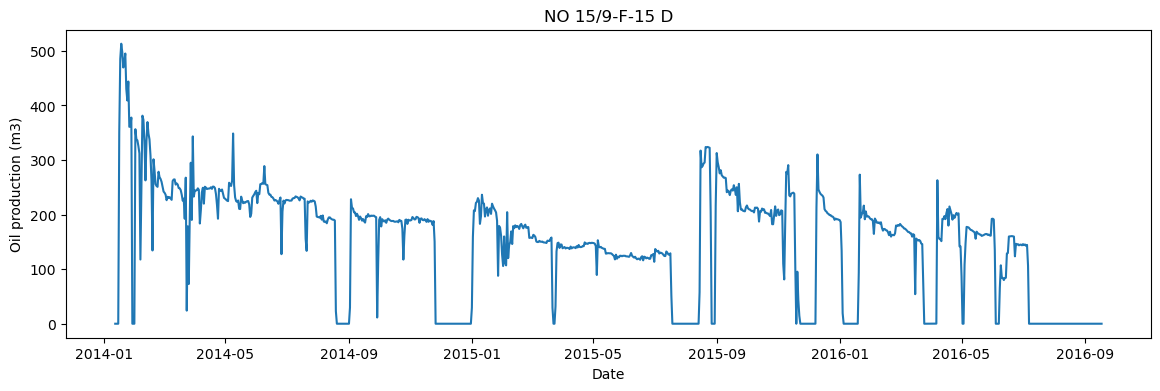

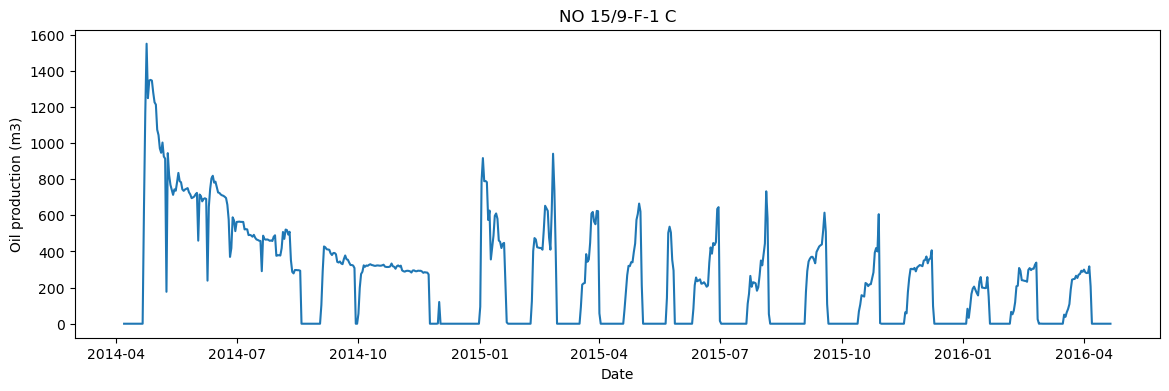

In [31]:
# Analyze each well's production data
# Plot one chart per well
for well in wells:
    well_data = df[df["WELL_BORE_CODE"] == well]

    plt.figure(figsize=(14, 4))
    plt.plot(
        well_data["DATEPRD"],
        well_data["BORE_OIL_VOL"]
    )
    plt.title(well)
    plt.xlabel("Date")
    plt.ylabel("Oil production (m3)")

Well NO 15/9-F-12 H and NO 15/9-F-14 H have the longest date coverage (2008-2016).

In [32]:
df_12 = df[df['WELL_BORE_CODE'] == 'NO 15/9-F-12 H']
df_12.isna().sum()

DATEPRD                      0
WELL_BORE_CODE               0
ON_STREAM_HRS                0
AVG_DOWNHOLE_PRESSURE        6
AVG_DOWNHOLE_TEMPERATURE     6
AVG_DP_TUBING                6
AVG_ANNULUS_PRESS           13
AVG_CHOKE_SIZE_P            44
AVG_WHP_P                    0
AVG_WHT_P                    0
DP_CHOKE_SIZE                0
BORE_OIL_VOL                 0
FLOW_KIND                    0
dtype: int64

In [33]:
df_14 = df[df['WELL_BORE_CODE'] == 'NO 15/9-F-14 H']
df_14.isna().sum()

DATEPRD                       0
WELL_BORE_CODE                0
ON_STREAM_HRS                 0
AVG_DOWNHOLE_PRESSURE         6
AVG_DOWNHOLE_TEMPERATURE      6
AVG_DP_TUBING                 6
AVG_ANNULUS_PRESS           523
AVG_CHOKE_SIZE_P            196
AVG_WHP_P                     0
AVG_WHT_P                     0
DP_CHOKE_SIZE                 0
BORE_OIL_VOL                  0
FLOW_KIND                     0
dtype: int64

Well NO 15/9-F-12 H has fewer missing values in AVG_ANNULUS_PRESS and AVG_CHOKE_SIZE_P, so we'll use this well's data.

In [34]:
print("Dimension: ", df_12.shape)
print("Top 5 lines:", df_12.head())
del df

Dimension:  (3056, 13)
Top 5 lines:        DATEPRD  WELL_BORE_CODE  ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  \
328 2008-02-12  NO 15/9-F-12 H          11.50             308.055940   
332 2008-02-13  NO 15/9-F-12 H          24.00             303.033518   
336 2008-02-14  NO 15/9-F-12 H          22.50             295.586061   
340 2008-02-15  NO 15/9-F-12 H          23.15             297.662702   
344 2008-02-16  NO 15/9-F-12 H          24.00             295.935519   

     AVG_DOWNHOLE_TEMPERATURE  AVG_DP_TUBING  AVG_ANNULUS_PRESS  \
328                104.418090     201.250000          18.639557   
332                105.402696     182.144942          16.466641   
336                105.775486     181.867887          12.659589   
340                105.751875     180.832060           5.264052   
344                105.811114     180.501045          12.384634   

     AVG_CHOKE_SIZE_P   AVG_WHP_P  AVG_WHT_P  DP_CHOKE_SIZE  BORE_OIL_VOL  \
328         14.484431  106.805939  16.294718      9

In [35]:
# Remove duplicates
df_12.drop_duplicates(inplace=True)
print("Dimension: ", df_12.shape)

Dimension:  (3056, 13)


There are no duplicates because the dimension remains the same